In [1]:
# CELDA 1: Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import psycopg2
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías importadas correctamente
   pandas      2.2.2
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.6


In [2]:
# CELDA 2: Conexión a PostgreSQL y carga de datos
conn = psycopg2.connect(
    host='localhost', port=5432,
    database='divisas_db', user='etl_user', password='etl1234'
)

query = """
SELECT 
    moneda_destino,
    tasa_cambio,
    inversa,
    fecha_extraccion,
    fecha_actualizacion_api
FROM tasas_cambio
ORDER BY fecha_extraccion ASC
"""

df = pd.read_sql(query, conn)
conn.close()

df['fecha_extraccion'] = pd.to_datetime(df['fecha_extraccion'])
df['dia'] = (df['fecha_extraccion'] - df['fecha_extraccion'].min()).dt.days

print(f"✅ Datos cargados desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n🏙️  Monedas disponibles:")
print(df['moneda_destino'].value_counts())
df.head()

✅ Datos cargados desde PostgreSQL
   Filas    : 728
   Columnas : 6

🏙️  Monedas disponibles:
moneda_destino
EUR    91
AUD    91
CAD    91
MXN    91
BRL    91
JPY    91
GBP    91
COP    91
Name: count, dtype: int64


,moneda_destino,tasa_cambio,inversa,fecha_extraccion,fecha_actualizacion_api,dia
0,EUR,0.854356,1.170472,2025-12-11 11:19:17.915282,simulado,0
1,AUD,1.401874,0.713331,2025-12-11 11:19:17.915282,simulado,0
2,CAD,1.351567,0.739882,2025-12-11 11:19:17.915282,simulado,0
3,MXN,17.846230,0.056034,2025-12-11 11:19:17.915282,simulado,0
4,BRL,5.110051,0.195693,2025-12-11 11:19:17.915282,simulado,0


In [3]:
# CELDA 3: Estadísticas descriptivas
vars_num = ['tasa_cambio', 'inversa', 'dia']

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(df[vars_num].describe().round(4))

print("\n📊 Estadísticas por moneda (tasa_cambio):")
print(df.groupby('moneda_destino')['tasa_cambio'].agg(['mean','std','min','max']).round(4))

📊 ESTADÍSTICAS DESCRIPTIVAS
       tasa_cambio   inversa       dia
count     728.0000  728.0000  728.0000
mean      492.3038    0.5274   44.9890
std      1234.6326    0.5055   26.2673
min         0.7296    0.0003    0.0000
25%         1.2176    0.0435   22.0000
50%         3.2466    0.4482   45.0000
75%        52.1321    0.8485   68.0000
max      3827.9854    1.3707   89.0000

📊 Estadísticas por moneda (tasa_cambio):
                     mean      std        min        max
moneda_destino                                          
AUD                1.4057   0.0157     1.3773     1.4309
BRL                5.1661   0.0605     5.0622     5.2677
CAD                1.3577   0.0148     1.3311     1.3844
COP             3753.5956  44.9266  3678.0464  3827.9854
EUR                0.8578   0.0096     0.8430     0.8772
GBP                0.7419   0.0080     0.7296     0.7588
JPY              157.7127   1.7624   154.7491   160.6642
MXN               17.5929   0.2123    17.2281    17.9265


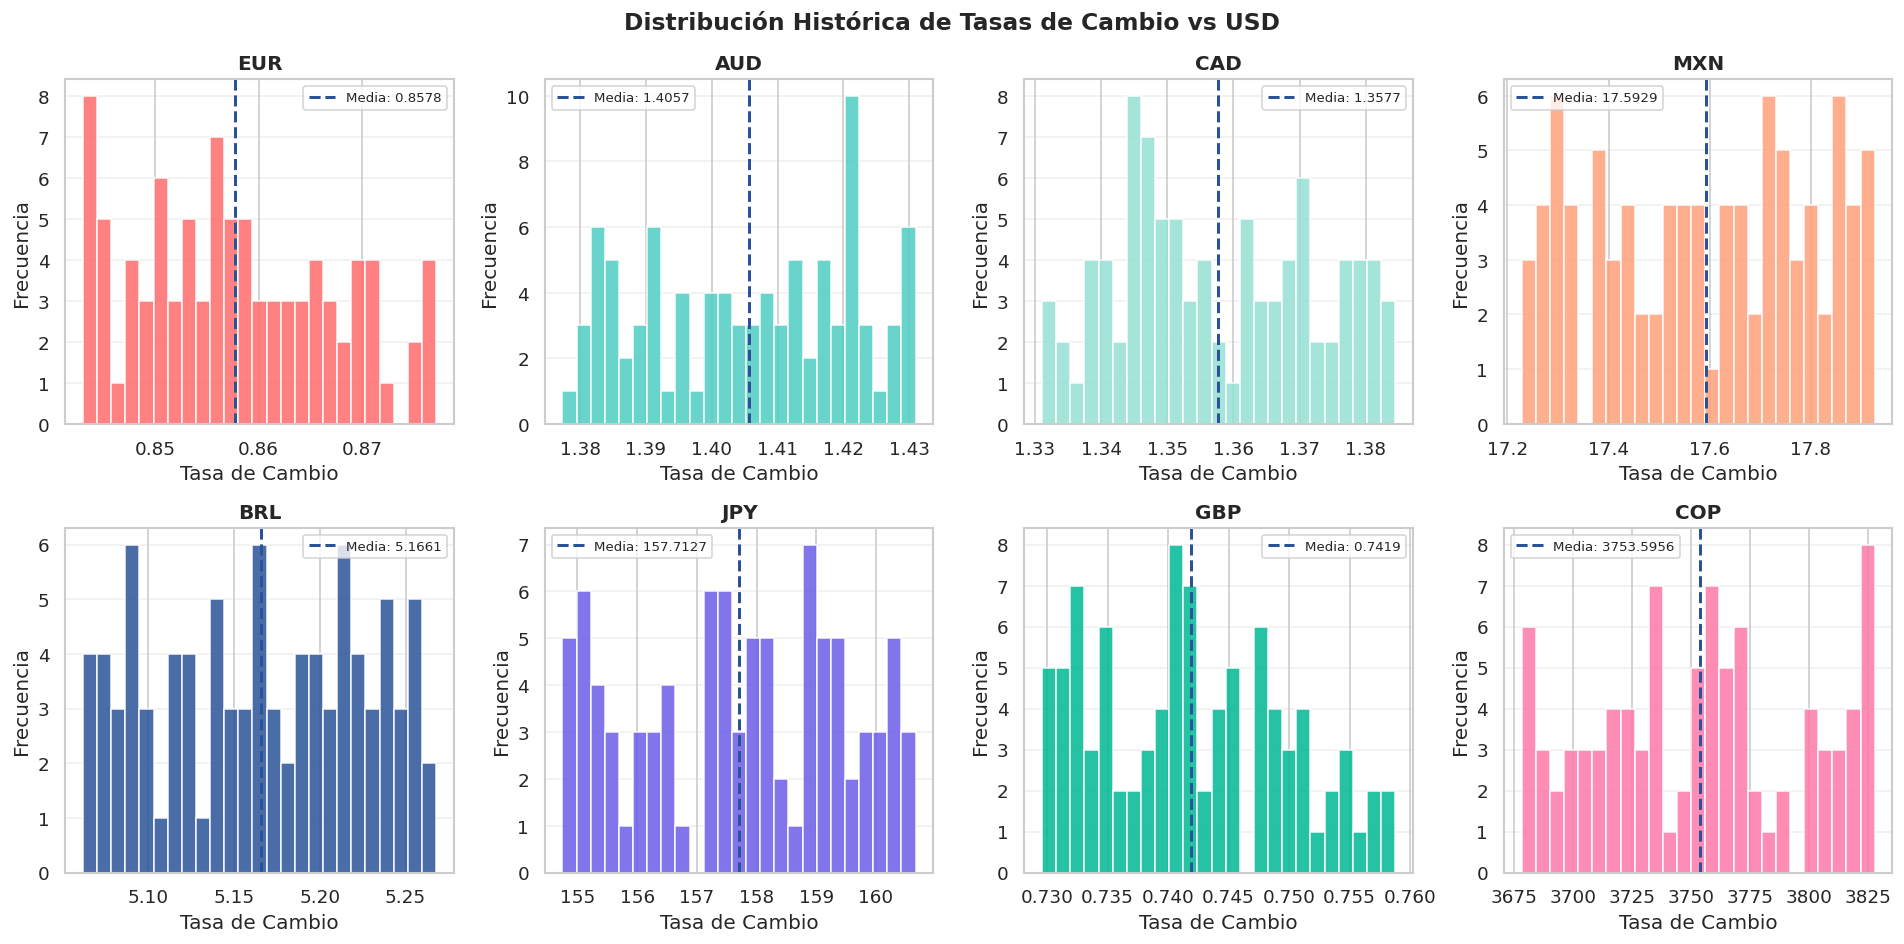

✅ Gráfica guardada en data/eda_distribuciones.png


In [4]:
# CELDA 4: Distribución histórica por moneda
monedas = df['moneda_destino'].unique()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribución Histórica de Tasas de Cambio vs USD', fontsize=14, fontweight='bold')

colores = ['#ff6b6b', '#4ecdc4', '#95e1d3', '#ffa07a', '#2a5298', '#6c5ce7', '#00b894', '#fd79a8']

for idx, (moneda, color) in enumerate(zip(monedas, colores)):
    ax = axes[idx // 4][idx % 4]
    datos = df[df['moneda_destino'] == moneda]['tasa_cambio']
    ax.hist(datos, bins=25, color=color, edgecolor='white', alpha=0.85)
    media = datos.mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8, label=f'Media: {media:.4f}')
    ax.set_title(moneda, fontweight='bold')
    ax.set_xlabel('Tasa de Cambio')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/eda_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada en data/eda_distribuciones.png")


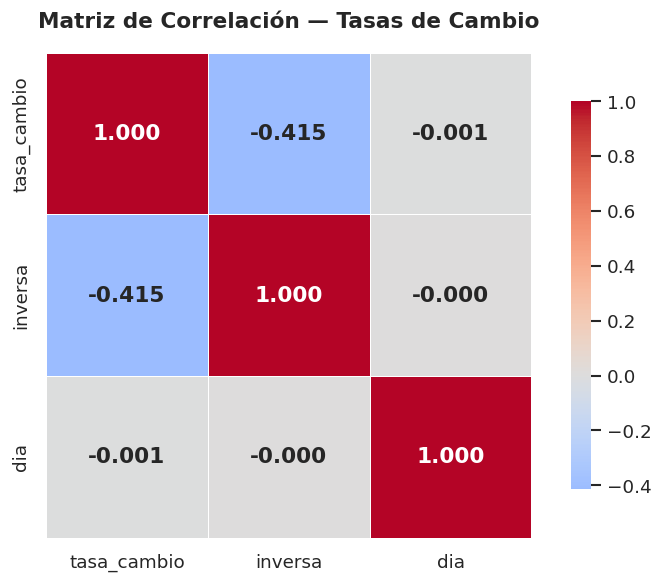


📊 Correlación con tasa_cambio:
dia       -0.0006
inversa   -0.4150
Name: tasa_cambio, dtype: float64


In [5]:
# CELDA 5: Matriz de correlación
corr = df[['tasa_cambio', 'inversa', 'dia']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.6, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 13, 'weight': 'bold'})
plt.title('Matriz de Correlación — Tasas de Cambio', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('data/eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Correlación con tasa_cambio:")
print(corr['tasa_cambio'].drop('tasa_cambio').sort_values(ascending=False).round(4))

📈 REGRESIÓN LINEAL SIMPLE — EUR
   Train: 72 muestras | Test: 19 muestras

📐 Ecuación del modelo:
   tasa_cambio = 0.855417 + (0.000045 × dia)

📊 MÉTRICAS:
   R²   : -0.0072 (-0.72%)
   RMSE : 0.008739
   MAE  : 0.007040


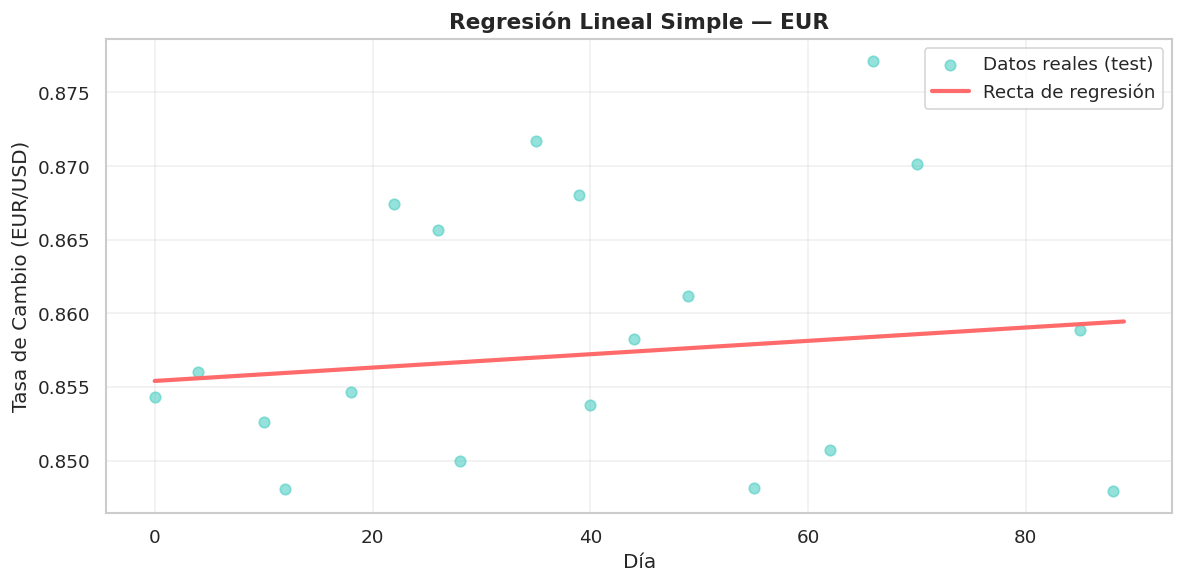

In [6]:
# CELDA 6: Regresión Lineal Simple (dia -> tasa_cambio para una moneda)
# Usamos EUR como ejemplo representativo
moneda_ejemplo = 'EUR'
datos_eur = df[df['moneda_destino'] == moneda_ejemplo].copy()

X_simple = datos_eur[['dia']].values
y = datos_eur['tasa_cambio'].values

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.20, random_state=42)

modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)
y_pred_simple = modelo_simple.predict(X_test)

print(f"📈 REGRESIÓN LINEAL SIMPLE — {moneda_ejemplo}")
print(f"   Train: {len(X_train)} muestras | Test: {len(X_test)} muestras")
print(f"\n📐 Ecuación del modelo:")
print(f"   tasa_cambio = {modelo_simple.intercept_:.6f} + ({modelo_simple.coef_[0]:.6f} × dia)")

# Métricas
r2   = r2_score(y_test, y_pred_simple)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_simple))
mae  = mean_absolute_error(y_test, y_pred_simple)

print(f"\n📊 MÉTRICAS:")
print(f"   R²   : {r2:.4f} ({r2*100:.2f}%)")
print(f"   RMSE : {rmse:.6f}")
print(f"   MAE  : {mae:.6f}")

# Gráfica
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(X_test, y_test, alpha=0.6, color='#4ecdc4', label='Datos reales (test)', s=40)
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line), color='#ff6b6b', linewidth=2.5, label='Recta de regresión')
ax.set_xlabel('Día')
ax.set_ylabel(f'Tasa de Cambio ({moneda_ejemplo}/USD)')
ax.set_title(f'Regresión Lineal Simple — {moneda_ejemplo}', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('data/regresion_simple.png', dpi=150, bbox_inches='tight')
plt.show()

📈 REGRESIÓN LINEAL MÚLTIPLE — Todas las monedas
   Features: ['dia', 'inversa']

📐 Ecuación:
   tasa_cambio = 1078.3241 + (-0.1853 × dia) + (-1060.1708 × inversa)

📊 MÉTRICAS:
   R²   : 0.1229 (12.29%)
   RMSE : 1089.0661
   MAE  : 815.6828


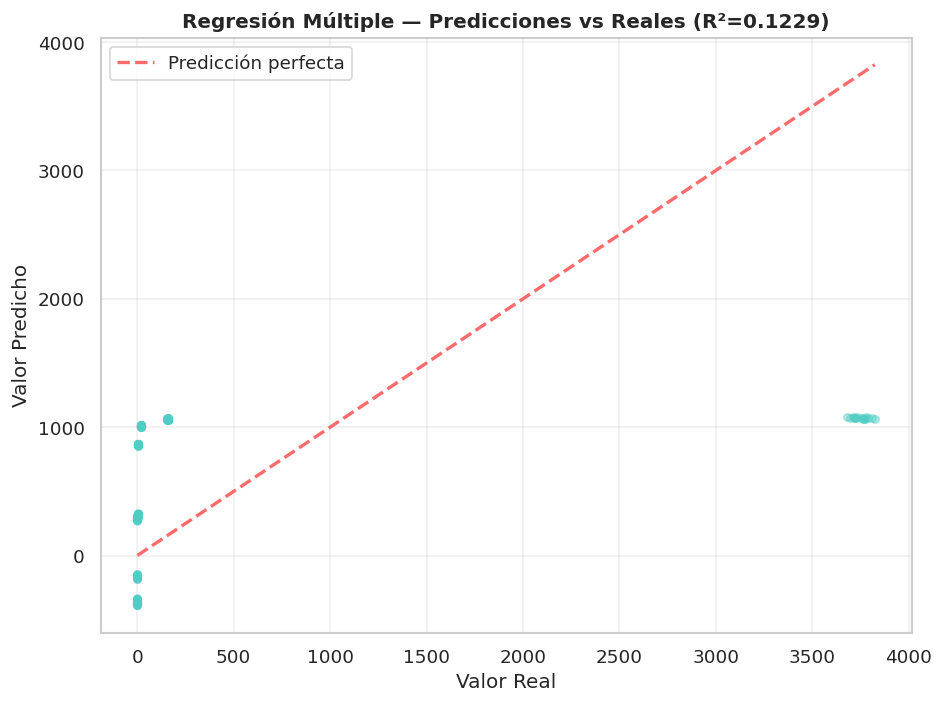

In [7]:
# CELDA 7: Regresión Lineal Múltiple (todas las monedas)
FEATURES = ['dia', 'inversa']

X_multi = df[FEATURES].values
y_multi = df['tasa_cambio'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)
y_pred_multi = modelo_multi.predict(X_test_m)

r2_m   = r2_score(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_multi))
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("📈 REGRESIÓN LINEAL MÚLTIPLE — Todas las monedas")
print(f"   Features: {FEATURES}")
print(f"\n📐 Ecuación:")
print(f"   tasa_cambio = {modelo_multi.intercept_:.4f} + ({modelo_multi.coef_[0]:.4f} × dia) + ({modelo_multi.coef_[1]:.4f} × inversa)")
print(f"\n📊 MÉTRICAS:")
print(f"   R²   : {r2_m:.4f} ({r2_m*100:.2f}%)")
print(f"   RMSE : {rmse_m:.4f}")
print(f"   MAE  : {mae_m:.4f}")

# Gráfica predicciones vs reales
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test_m, y_pred_multi, alpha=0.4, color='#4ecdc4', s=20)
minval, maxval = y_test_m.min(), y_test_m.max()
ax.plot([minval, maxval], [minval, maxval], color='#ff6b6b', linewidth=2, linestyle='--', label='Predicción perfecta')
ax.set_xlabel('Valor Real')
ax.set_ylabel('Valor Predicho')
ax.set_title(f'Regresión Múltiple — Predicciones vs Reales (R²={r2_m:.4f})', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('data/regresion_multiple.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# CELDA 8: OLS statsmodels + supuestos estadísticos
X_ols = sm.add_constant(df[FEATURES])
modelo_ols = sm.OLS(df['tasa_cambio'], X_ols).fit()
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:            tasa_cambio   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     75.41
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           1.77e-30
Time:                        00:41:16   Log-Likelihood:                -6146.0
No. Observations:                 728   AIC:                         1.230e+04
Df Residuals:                     725   BIC:                         1.231e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1028.2748     93.488     10.999      0.0

🧪 TEST DE SHAPIRO-WILK (Normalidad de residuos)
   Estadístico : 0.7234
   p-valor     : 0.0000
   Conclusión  : ❌ Residuos NO normales (p ≤ 0.05)

🧪 TEST DE BREUSCH-PAGAN (Homocedasticidad)
   Estadístico : 185.7905
   p-valor     : 0.0000
   Conclusión  : ❌ Heterocedasticidad (p ≤ 0.05)

🧪 FACTOR DE INFLACIÓN DE VARIANZA (VIF)
   dia       : VIF = 1.6364 ✅ OK
   inversa   : VIF = 1.6364 ✅ OK


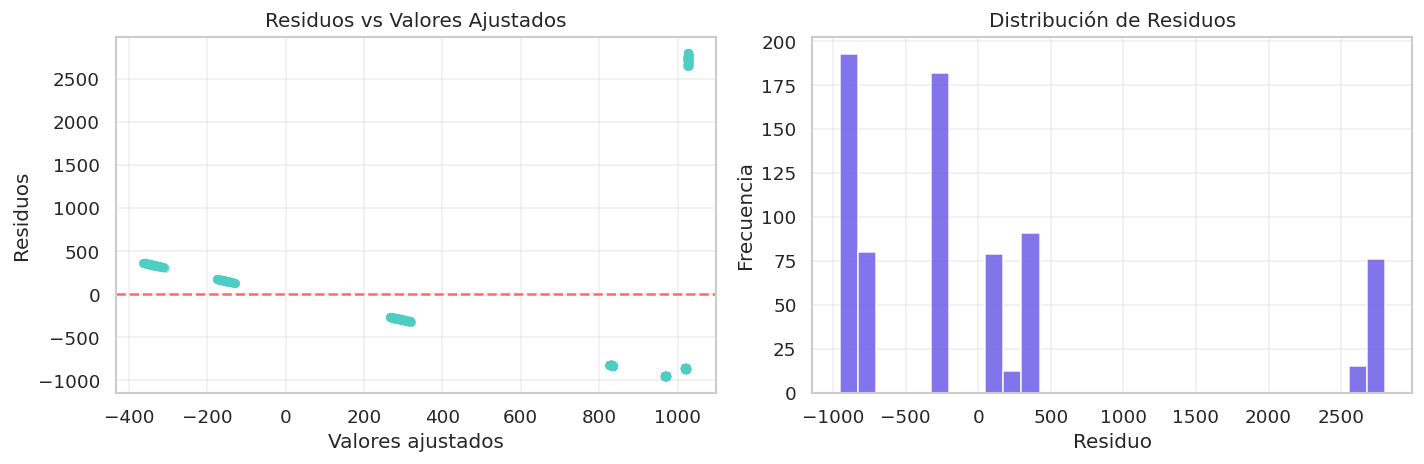

In [9]:
# CELDA 9: Tests de supuestos — Normalidad y Homocedasticidad
residuos = modelo_ols.resid

# Test de Shapiro-Wilk (normalidad)
stat_sw, p_sw = stats.shapiro(residuos[:200])  # muestra de 200 por límite del test
print("🧪 TEST DE SHAPIRO-WILK (Normalidad de residuos)")
print(f"   Estadístico : {stat_sw:.4f}")
print(f"   p-valor     : {p_sw:.4f}")
print(f"   Conclusión  : {'✅ Residuos normales (p > 0.05)' if p_sw > 0.05 else '❌ Residuos NO normales (p ≤ 0.05)'}")

# Test de Breusch-Pagan (homocedasticidad)
bp_test = het_breuschpagan(residuos, X_ols)
print(f"\n🧪 TEST DE BREUSCH-PAGAN (Homocedasticidad)")
print(f"   Estadístico : {bp_test[0]:.4f}")
print(f"   p-valor     : {bp_test[1]:.4f}")
print(f"   Conclusión  : {'✅ Homocedasticidad (p > 0.05)' if bp_test[1] > 0.05 else '❌ Heterocedasticidad (p ≤ 0.05)'}")

# VIF — Multicolinealidad
print(f"\n🧪 FACTOR DE INFLACIÓN DE VARIANZA (VIF)")
for i, col in enumerate(FEATURES):
    vif = variance_inflation_factor(df[FEATURES].values, i)
    print(f"   {col:10s}: VIF = {vif:.4f} {'✅ OK' if vif < 10 else '⚠️ Alta multicolinealidad'}")

# Gráfica de residuos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(modelo_ols.fittedvalues, residuos, alpha=0.4, color='#4ecdc4', s=20)
axes[0].axhline(0, color='#ff6b6b', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Valores ajustados')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Valores Ajustados')
axes[0].grid(alpha=0.3)

axes[1].hist(residuos, bins=30, color='#6c5ce7', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/supuestos_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

🔮 PREDICCIONES A 7 DÍAS POR MONEDA
Moneda  Tasa Actual  Pred. +7 días  Cambio %     MAE      R²
   AUD       1.4040         1.4061     0.150  0.0147 -0.1123
   BRL       5.1650         5.1487    -0.315  0.0600 -0.0280
   CAD       1.3577         1.3574    -0.019  0.0154 -0.0957
   COP    3753.0880      3732.2750    -0.555 34.4835 -0.3694
   EUR       0.8602         0.8598    -0.050  0.0070 -0.0072
   GBP       0.7444         0.7413    -0.421  0.0078 -0.0624
   JPY     157.9017       158.1867     0.180  1.3718  0.0598
   MXN      17.5791        17.6205     0.235  0.2172 -0.0422


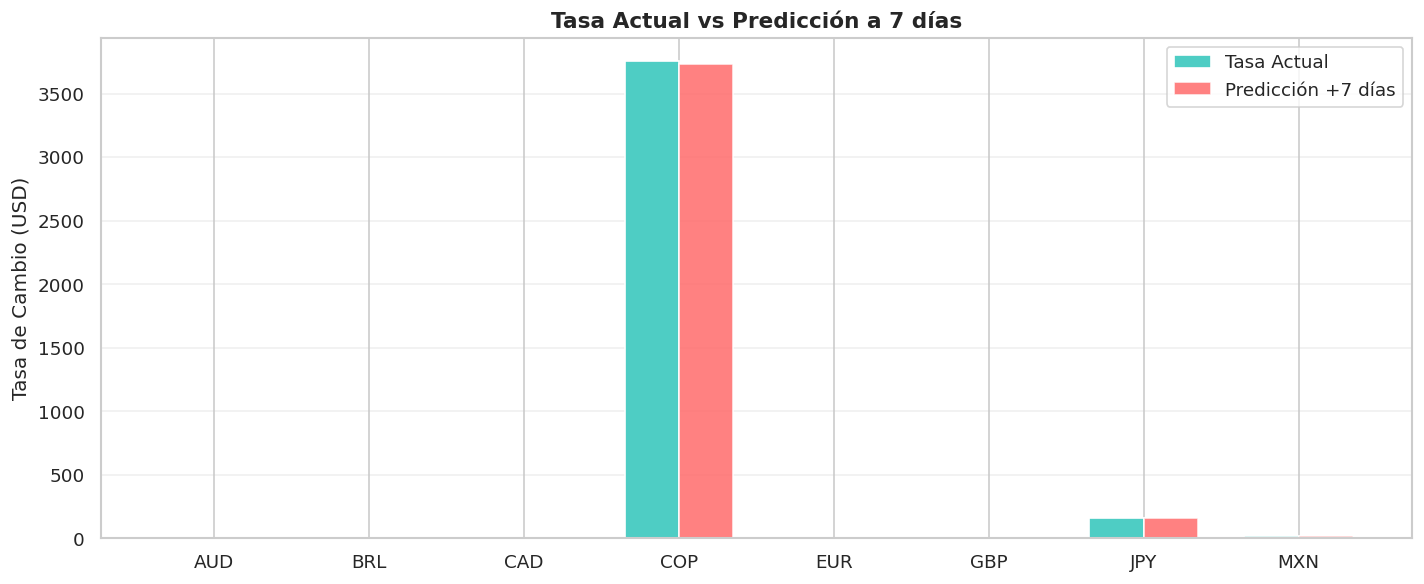


✅ Análisis ML completo


In [10]:
# CELDA 10: Predicciones a 7 días por moneda
print("🔮 PREDICCIONES A 7 DÍAS POR MONEDA")
print("="*55)

resultados = []
for moneda in df['moneda_destino'].unique():
    datos = df[df['moneda_destino'] == moneda].copy()
    X = datos[['dia']]
    y = datos['tasa_cambio']
    
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    modelo = LinearRegression()
    modelo.fit(X_tr, y_tr)
    
    dia_futuro = datos['dia'].max() + 7
    pred = modelo.predict([[dia_futuro]])[0]
    mae = mean_absolute_error(y_te, modelo.predict(X_te))
    r2  = r2_score(y_te, modelo.predict(X_te))
    
    resultados.append({
        'Moneda': moneda,
        'Tasa Actual': round(y.iloc[-1], 4),
        'Pred. +7 días': round(pred, 4),
        'Cambio %': round((pred - y.iloc[-1]) / y.iloc[-1] * 100, 3),
        'MAE': round(mae, 4),
        'R²': round(r2, 4)
    })

res_df = pd.DataFrame(resultados).sort_values('Moneda')
print(res_df.to_string(index=False))

# Gráfica resumen
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(res_df))
w = 0.35
ax.bar(x - w/2, res_df['Tasa Actual'], w, label='Tasa Actual', color='#4ecdc4')
ax.bar(x + w/2, res_df['Pred. +7 días'], w, label='Predicción +7 días', color='#ff6b6b', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(res_df['Moneda'])
ax.set_title('Tasa Actual vs Predicción a 7 días', fontsize=13, fontweight='bold')
ax.set_ylabel('Tasa de Cambio (USD)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('data/predicciones_7dias.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Análisis ML completo")